<a href="https://colab.research.google.com/github/Harshini-codes9/ML-projects/blob/main/MLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can upload files directly from your local system to the Colab environment. Once uploaded, you can then read them into a pandas DataFrame.

In [1]:
from google.colab import files
import pandas as pd

# This will open a file browser where you can select your CSV file
uploaded = files.upload()

# Get the name of the uploaded file(s)
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Read the CSV file into a pandas DataFrame
  df = pd.read_csv(fn)
  display(df.head())


Saving Country.csv to Country.csv
User uploaded file "Country.csv" with length 131845 bytes


,CountryCode,ShortName,TableName,LongName,Alpha2Code,CurrencyUnit,SpecialNotes,Region,IncomeGroup,Wb2Code,...,GovernmentAccountingConcept,ImfDataDisseminationStandard,LatestPopulationCensus,LatestHouseholdSurvey,SourceOfMostRecentIncomeAndExpenditureData,VitalRegistrationComplete,LatestAgriculturalCensus,LatestIndustrialData,LatestTradeData,LatestWaterWithdrawalData
0,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2013.0,2000.0
1,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,Budgetary central government,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2011.0,2013.0,2006.0
2,DZA,Algeria,Algeria,People's Democratic Republic of Algeria,DZ,Algerian dinar,NaN,Middle East & North Africa,Upper middle income,DZ,...,Budgetary central government,General Data Dissemination System (GDDS),2008,"Multiple Indicator Cluster Survey (MICS), 2012","Integrated household survey (IHS), 1995",NaN,NaN,2010.0,2013.0,2001.0
3,ASM,American Samoa,American Samoa,American Samoa,AS,U.S. dollar,NaN,East Asia & Pacific,Upper middle income,AS,...,NaN,NaN,2010,NaN,NaN,Yes,2007,NaN,NaN,NaN
4,ADO,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,NaN,2011. Population data compiled from administra...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN


In [2]:
import pandas as pd
import numpy as np

# Check your dataframe first
print(df.shape)           # how many rows & columns
print(df.head())          # first 5 rows
print(df.dtypes)          # column types
print(df.isnull().sum())  # missing values per column


(247, 31)
  CountryCode       ShortName       TableName  \
0         AFG     Afghanistan     Afghanistan   
1         ALB         Albania         Albania   
2         DZA         Algeria         Algeria   
3         ASM  American Samoa  American Samoa   
4         ADO         Andorra         Andorra   

                                  LongName Alpha2Code    CurrencyUnit  \
0             Islamic State of Afghanistan         AF  Afghan afghani   
1                      Republic of Albania         AL    Albanian lek   
2  People's Democratic Republic of Algeria         DZ  Algerian dinar   
3                           American Samoa         AS     U.S. dollar   
4                  Principality of Andorra         AD            Euro   

                                        SpecialNotes  \
0  Fiscal year end: March 20; reporting period fo...   
1                                                NaN   
2                                                NaN   
3                               

In [3]:
threshold = 0.4  # 40%

missing_ratio = df.isnull().mean()  # % missing per column

# See what will be dropped
print("Columns being dropped:")
print(missing_ratio[missing_ratio > threshold])

# Drop them
df = df.loc[:, missing_ratio <= threshold]

print(f"\nShape after dropping: {df.shape}")

Columns being dropped:
NationalAccountsReferenceYear    0.781377
LendingCategory                  0.417004
OtherGroups                      0.761134
AlternativeConversionFactor      0.809717
ExternalDebtReportingStatus      0.497976
LatestHouseholdSurvey            0.404858
VitalRegistrationComplete        0.546559
LatestAgriculturalCensus         0.425101
LatestIndustrialData             0.542510
dtype: float64

Shape after dropping: (247, 22)


In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")

Numeric columns (2): ['LatestTradeData', 'LatestWaterWithdrawalData']

Categorical columns (20): ['CountryCode', 'ShortName', 'TableName', 'LongName', 'Alpha2Code', 'CurrencyUnit', 'SpecialNotes', 'Region', 'IncomeGroup', 'Wb2Code', 'NationalAccountsBaseYear', 'SnaPriceValuation', 'SystemOfNationalAccounts', 'PppSurveyYear', 'BalanceOfPaymentsManualInUse', 'SystemOfTrade', 'GovernmentAccountingConcept', 'ImfDataDisseminationStandard', 'LatestPopulationCensus', 'SourceOfMostRecentIncomeAndExpenditureData']


In [5]:
# Fill numeric columns with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode (most frequent value)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify no nulls remain
print("Nulls remaining:", df.isnull().sum().sum())  # should print 0

Nulls remaining: 0


/tmp/ipykernel_3132/1463868254.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3132/1463868254.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3132/1463868254.py:7: FutureWarning: A value is trying to be set on a 

In [6]:
from sklearn.preprocessing import LabelEncoder

# Version A — Label Encoding (used for ANOVA, correlation tests)
df_label = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_label[col] = le.fit_transform(df[col].astype(str))

# Version B — Keep original (used for Chi-squared, groupby plots)
df_original = df.copy()

print("Label-encoded df shape:", df_label.shape)
print("Original df shape:", df_original.shape)

Label-encoded df shape: (247, 22)
Original df shape: (247, 22)


In [7]:
print("=== FINAL SUMMARY ===")
print(f"Total columns: {df_label.shape[1]}")
print(f"Numeric cols: {len(num_cols)}")
print(f"Categorical cols: {len(cat_cols)}")
print(f"Any nulls left: {df_label.isnull().sum().sum()}")
print(f"\nSample data:")
df_label.head()

=== FINAL SUMMARY ===
Total columns: 22
Numeric cols: 2
Categorical cols: 20
Any nulls left: 0

Sample data:


,CountryCode,ShortName,TableName,LongName,Alpha2Code,CurrencyUnit,SpecialNotes,Region,IncomeGroup,Wb2Code,...,SystemOfNationalAccounts,PppSurveyYear,BalanceOfPaymentsManualInUse,SystemOfTrade,GovernmentAccountingConcept,ImfDataDisseminationStandard,LatestPopulationCensus,SourceOfMostRecentIncomeAndExpenditureData,LatestTradeData,LatestWaterWithdrawalData
0,2,0,0,64,7,0,75,5,2,7,...,1,0,0,0,1,0,1,37,2013.0,2000.0
1,4,1,1,118,9,1,23,1,4,9,...,1,2,0,0,0,0,19,55,2013.0,2006.0
2,57,2,2,108,58,2,23,3,4,57,...,0,0,0,1,0,0,16,31,2013.0,2001.0
3,9,3,3,0,13,139,23,0,4,13,...,0,1,0,1,1,0,18,44,2013.0,2005.0
4,1,4,4,114,5,46,23,1,1,5,...,0,0,0,1,1,0,20,44,2006.0,2005.0


In [8]:
from itertools import combinations
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

results = []  # all test results will collect here
print("Imports done!")

Imports done!


In [9]:
print(f"Testing {len(list(combinations(num_cols, 2)))} numeric pairs...")

for c1, c2 in combinations(num_cols, 2):
    pair = df_label[[c1, c2]].dropna()
    if len(pair) < 10:      # skip if too few rows
        continue

    x, y = pair[c1], pair[c2]

    # Pearson
    r, p = stats.pearsonr(x, y)
    results.append({
        'feature_1': c1, 'feature_2': c2,
        'test_used': 'Pearson',
        'statistic': round(r, 4),
        'p_value': round(p, 6),
        'effect_size': round(abs(r), 4)   # |r| is the effect size
    })

    # Spearman
    r, p = stats.spearmanr(x, y)
    results.append({
        'feature_1': c1, 'feature_2': c2,
        'test_used': 'Spearman',
        'statistic': round(r, 4),
        'p_value': round(p, 6),
        'effect_size': round(abs(r), 4)
    })

    # Kendall
    r, p = stats.kendalltau(x, y)
    results.append({
        'feature_1': c1, 'feature_2': c2,
        'test_used': 'Kendall',
        'statistic': round(r, 4),
        'p_value': round(p, 6),
        'effect_size': round(abs(r), 4)
    })

    # Mutual Information (non-linear catch-all)
    mi = mutual_info_regression(pair[[c1]], y, random_state=42)[0]
    results.append({
        'feature_1': c1, 'feature_2': c2,
        'test_used': 'MutualInfo',
        'statistic': round(mi, 4),
        'p_value': None,                  # MI has no p-value
        'effect_size': round(mi, 4)
    })

print(f"Done! {len(results)} results so far.")

Testing 1 numeric pairs...
Done! 4 results so far.


In [10]:
print(f"Testing {len(cat_cols) * len(num_cols)} categorical-numeric pairs...")

for cat in cat_cols:
    for num in num_cols:
        pair = df_original[[cat, num]].dropna()
        if len(pair) < 10:
            continue

        # Group numeric values by each category level
        groups = [
            group[num].values
            for _, group in pair.groupby(cat)
            if len(group) >= 2          # need at least 2 values per group
        ]

        if len(groups) < 2:             # need at least 2 groups
            continue

        f_stat, p = stats.f_oneway(*groups)

        # Effect size = Eta-squared (how much variance is explained)
        grand_mean = pair[num].mean()
        ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
        ss_total = sum((pair[num] - grand_mean)**2)
        eta_sq = ss_between / ss_total if ss_total != 0 else 0

        results.append({
            'feature_1': cat, 'feature_2': num,
            'test_used': 'ANOVA',
            'statistic': round(f_stat, 4),
            'p_value': round(p, 6),
            'effect_size': round(eta_sq, 4)
        })

print(f"Done! {len(results)} results so far.")

Testing 40 categorical-numeric pairs...
Done! 30 results so far.


In [11]:
print(f"Testing {len(list(combinations(cat_cols, 2)))} categorical pairs...")

for c1, c2 in combinations(cat_cols, 2):
    pair = df_original[[c1, c2]].dropna()
    if len(pair) < 10:
        continue

    contingency_table = pd.crosstab(pair[c1], pair[c2])

    # Need at least 2x2 table
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        continue

    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

    # Effect size = Cramer's V (0 = no association, 1 = perfect)
    n = len(pair)
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

    results.append({
        'feature_1': c1, 'feature_2': c2,
        'test_used': 'ChiSquared',
        'statistic': round(chi2, 4),
        'p_value': round(p, 6),
        'effect_size': round(cramers_v, 4)
    })

print(f"Done! Total results: {len(results)}")

Testing 190 categorical pairs...
Done! Total results: 201


In [12]:
results_df = pd.DataFrame(results)

# Add significance flag
results_df['significant'] = results_df['p_value'].apply(
    lambda p: 'Yes' if (p is not None and p < 0.05) else 'No/NA'
)

# Sort by effect size (strongest relationships first)
results_df = results_df.sort_values('effect_size', ascending=False)

# Reset index
results_df = results_df.reset_index(drop=True)

print(f"Total relationships found: {len(results_df)}")
print(f"Significant pairs (p<0.05): {(results_df['significant']=='Yes').sum()}")
results_df.head(20)

Total relationships found: 201
Significant pairs (p<0.05): 64


,feature_1,feature_2,test_used,statistic,p_value,effect_size,significant
0,CountryCode,LongName,ChiSquared,60762.0,0.239452,1.0,No/NA
1,CountryCode,NationalAccountsBaseYear,ChiSquared,9880.0,0.386100,1.0,No/NA
2,CountryCode,Wb2Code,ChiSquared,60515.0,0.239897,1.0,No/NA
3,CountryCode,SnaPriceValuation,ChiSquared,247.0,0.470078,1.0,No/NA
4,CountryCode,IncomeGroup,ChiSquared,988.0,0.458161,1.0,No/NA
5,CountryCode,Region,ChiSquared,1482.0,0.451232,1.0,No/NA
6,CountryCode,SpecialNotes,ChiSquared,36556.0,0.291094,1.0,No/NA
7,CountryCode,CurrencyUnit,ChiSquared,36556.0,0.291094,1.0,No/NA
8,CountryCode,Alpha2Code,ChiSquared,60021.0,0.240791,1.0,No/NA
9,TableName,LongName,ChiSquared,60762.0,0.239452,1.0,No/NA


In [13]:
results_df.to_csv('relationships.csv', index=False)
print("Saved to relationships.csv!")

# Quick summary by test type
print("\nResults breakdown by test:")
print(results_df['test_used'].value_counts())

# Top 10 strongest relationships
print("\nTop 10 strongest relationships:")
results_df[results_df['significant'] == 'Yes'].head(10)[
    ['feature_1', 'feature_2', 'test_used', 'effect_size', 'p_value']
]

Saved to relationships.csv!

Results breakdown by test:
test_used
ChiSquared    171
ANOVA          26
Spearman        1
Kendall         1
Pearson         1
MutualInfo      1
Name: count, dtype: int64

Top 10 strongest relationships:


,feature_1,feature_2,test_used,effect_size,p_value
93,CurrencyUnit,Region,ChiSquared,0.9465,0.000000
94,CurrencyUnit,GovernmentAccountingConcept,ChiSquared,0.9439,0.000112
95,CurrencyUnit,SnaPriceValuation,ChiSquared,0.8983,0.003149
96,CurrencyUnit,NationalAccountsBaseYear,ChiSquared,0.8980,0.000000
97,CurrencyUnit,LatestPopulationCensus,ChiSquared,0.8860,0.000000
98,CurrencyUnit,SourceOfMostRecentIncomeAndExpenditureData,ChiSquared,0.8429,0.000000
99,CurrencyUnit,IncomeGroup,ChiSquared,0.8222,0.016283
105,SpecialNotes,SourceOfMostRecentIncomeAndExpenditureData,ChiSquared,0.7841,0.037965
115,NationalAccountsBaseYear,GovernmentAccountingConcept,ChiSquared,0.6805,0.000000
117,ImfDataDisseminationStandard,SourceOfMostRecentIncomeAndExpenditureData,ChiSquared,0.6555,0.000552


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder to save all plots
os.makedirs('plots', exist_ok=True)

# Style
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 100

# Get top pairs (significant only, top 20)
top_pairs = results_df[results_df['significant'] == 'Yes'].head(20)

print(f"Generating plots for top {len(top_pairs)} relationships...")

Generating plots for top 20 relationships...


In [15]:
num_num = top_pairs[top_pairs['test_used'].isin(['Pearson', 'Spearman', 'Kendall'])]
# Keep only unique pairs (Pearson is enough to plot)
num_num = num_num[num_num['test_used'] == 'Pearson'].head(10)

for _, row in num_num.iterrows():
    c1, c2 = row['feature_1'], row['feature_2']
    pair = df_label[[c1, c2]].dropna()

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.regplot(data=pair, x=c1, y=c2, ax=ax,
                scatter_kws={'alpha': 0.4, 's': 20},
                line_kws={'color': 'red', 'linewidth': 2})

    ax.set_title(f'{c1} vs {c2}\nPearson r={row["statistic"]}  '
                 f'p={row["p_value"]}  Effect={row["effect_size"]}',
                 fontsize=11)
    ax.set_xlabel(c1)
    ax.set_ylabel(c2)

    plt.tight_layout()
    plt.savefig(f'plots/scatter_{c1}_vs_{c2}.png')
    plt.show()
    plt.close()

print("Scatter plots done!")

Scatter plots done!


In [16]:
anova_pairs = top_pairs[top_pairs['test_used'] == 'ANOVA'].head(10)

for _, row in anova_pairs.iterrows():
    cat, num = row['feature_1'], row['feature_2']
    pair = df_original[[cat, num]].dropna()

    # Limit to top 8 categories so plot stays readable
    top_cats = pair[cat].value_counts().head(8).index
    pair = pair[pair[cat].isin(top_cats)]

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=pair, x=cat, y=num, ax=ax, palette='husl')

    ax.set_title(f'{cat} vs {num}\nANOVA F={row["statistic"]}  '
                 f'p={row["p_value"]}  Eta²={row["effect_size"]}',
                 fontsize=11)
    ax.set_xlabel(cat)
    ax.set_ylabel(num)
    plt.xticks(rotation=30, ha='right')

    plt.tight_layout()
    plt.savefig(f'plots/boxplot_{cat}_vs_{num}.png')
    plt.show()
    plt.close()

print("Box plots done!")

Box plots done!


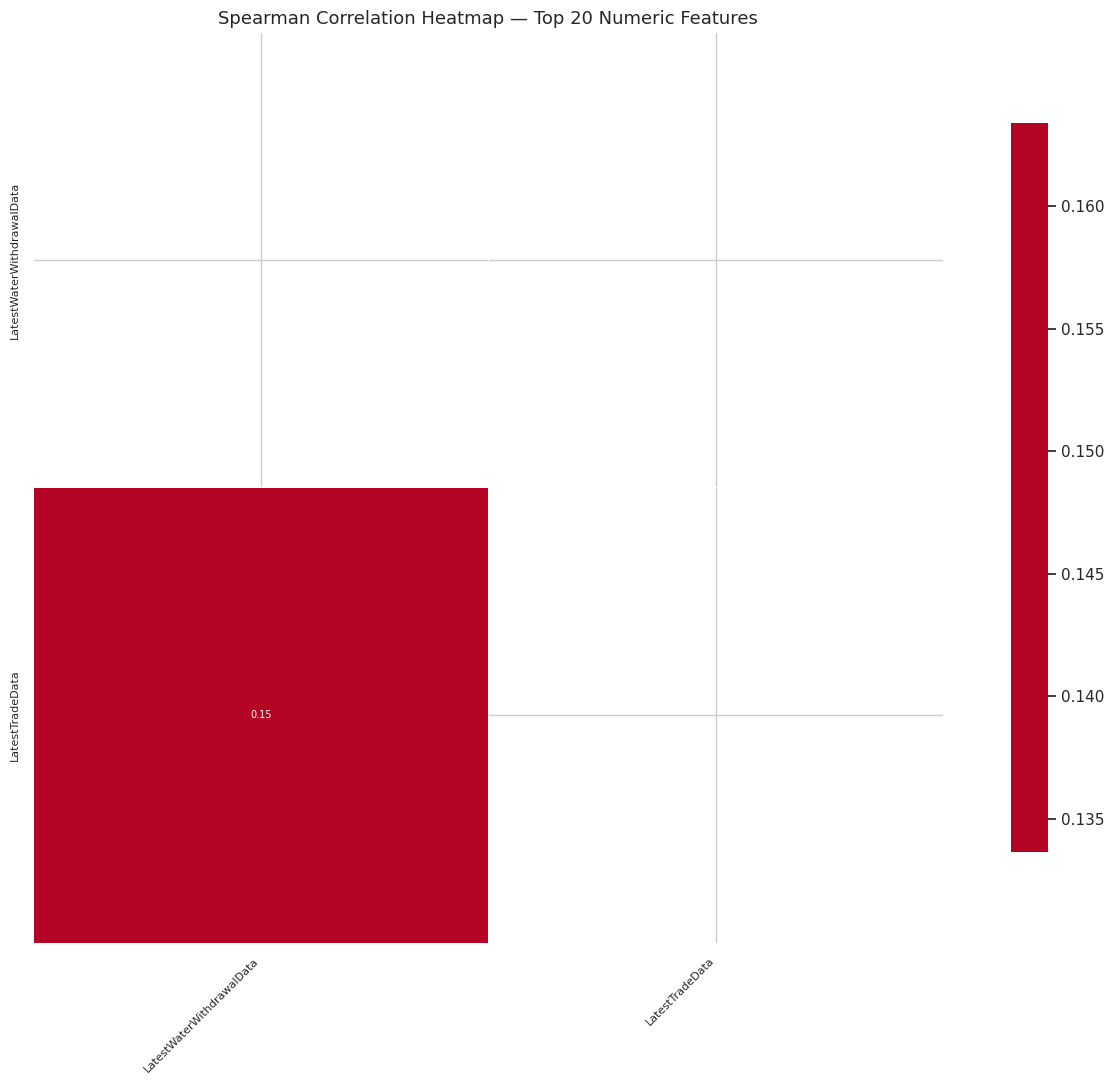

Heatmap done!


In [17]:
# Pick top 20 numeric columns by variance
top_num_cols = df_label[num_cols].var().sort_values(ascending=False).head(20).index.tolist()

corr_matrix = df_label[top_num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='coolwarm', center=0,
    linewidths=0.4, square=True,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Spearman Correlation Heatmap — Top 20 Numeric Features', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.savefig('plots/heatmap_correlations.png')
plt.show()
plt.close()

print("Heatmap done!")

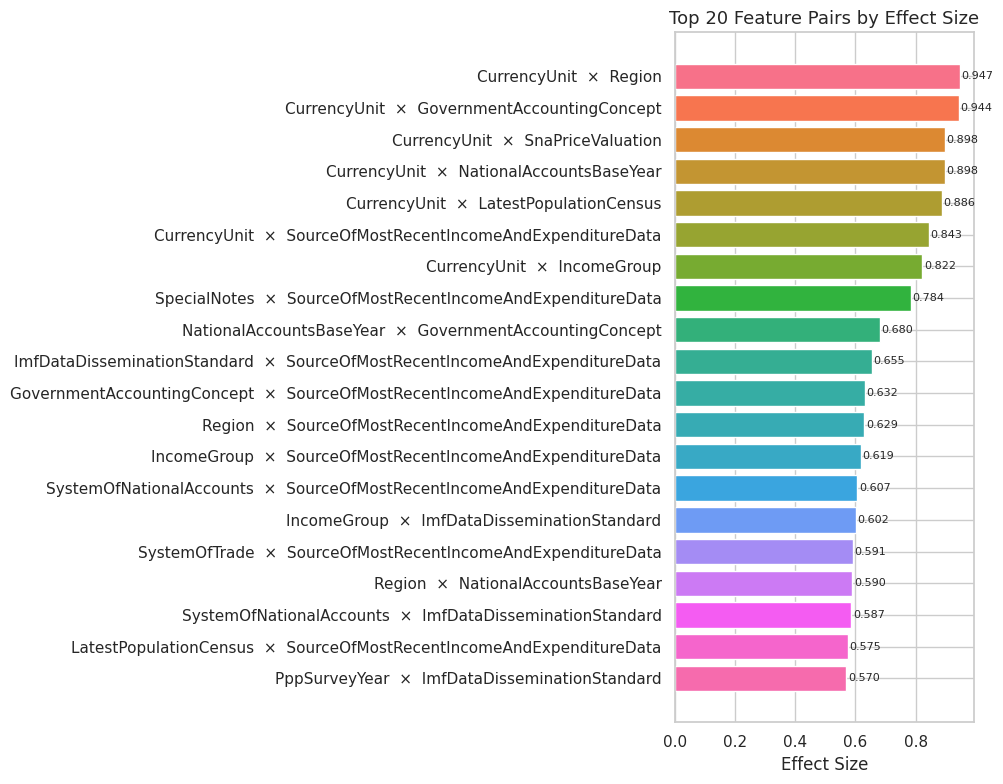

Bar chart done!


In [18]:
# One row per unique pair (take strongest test per pair)
top20 = (results_df[results_df['significant'] == 'Yes']
         .sort_values('effect_size', ascending=False)
         .drop_duplicates(subset=['feature_1', 'feature_2'])
         .head(20))

top20['pair_label'] = top20['feature_1'] + '  ×  ' + top20['feature_2']

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20['pair_label'], top20['effect_size'],
               color=sns.color_palette('husl', len(top20)))

ax.set_xlabel('Effect Size', fontsize=12)
ax.set_title('Top 20 Feature Pairs by Effect Size', fontsize=13)
ax.invert_yaxis()   # strongest at top

# Add value labels on bars
for bar, val in zip(bars, top20['effect_size']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plots/top20_effect_sizes.png')
plt.show()
plt.close()

print("Bar chart done!")

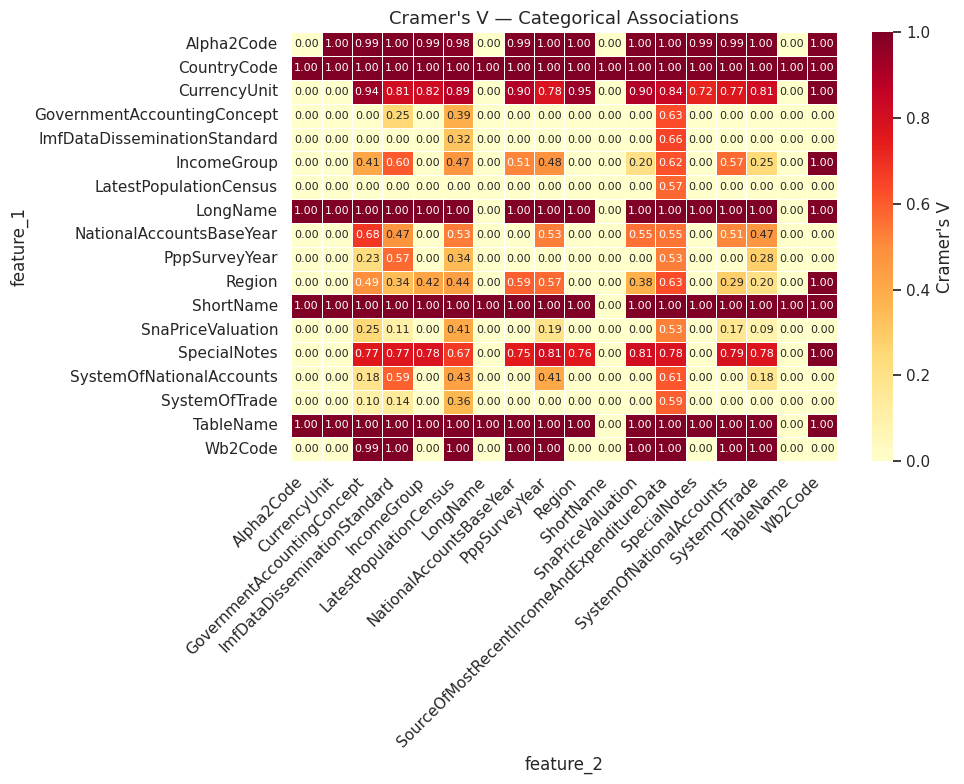

Chi-squared heatmap done!


In [19]:
chi_pairs = results_df[results_df['test_used'] == 'ChiSquared'].copy()

if len(chi_pairs) > 0:
    # Pivot into a matrix for heatmap
    chi_pivot = chi_pairs.pivot_table(
        index='feature_1', columns='feature_2',
        values='effect_size', aggfunc='max'
    ).fillna(0)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(chi_pivot, ax=ax,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                cmap='YlOrRd', linewidths=0.4,
                cbar_kws={'label': "Cramer's V"})

    ax.set_title("Cramer's V — Categorical Associations", fontsize=13)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('plots/chi_squared_cramersV.png')
    plt.show()
    plt.close()
    print("Chi-squared heatmap done!")
else:
    print("No categorical pairs found — skipping this plot.")

In [20]:
import statsmodels.api as sm

# Pick top 3 numeric pairs for partial regression
top3 = num_num.head(3)

for _, row in top3.iterrows():
    c1, c2 = row['feature_1'], row['feature_2']

    # Use all numeric cols except c1/c2 as controls (max 5 to keep it fast)
    controls = [c for c in num_cols if c not in [c1, c2]][:5]
    cols_needed = [c1, c2] + controls
    subset = df_label[cols_needed].dropna()

    X = sm.add_constant(subset[controls + [c1]])
    y = subset[c2]
    model = sm.OLS(y, X).fit()

    fig, ax = plt.subplots(figsize=(7, 5))
    sm.graphics.plot_partregress(
        endog=c2, exog_i=c1,
        exog_others=controls,
        data=subset, ax=ax,
        obs_labels=False
    )
    ax.set_title(f'Partial Regression: {c1} → {c2}\n'
                 f'(controlling for {", ".join(controls)})', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'plots/partial_reg_{c1}_vs_{c2}.png')
    plt.show()
    plt.close()

print("Partial regression plots done!")

Partial regression plots done!


In [29]:
import zipfile

zip_name = 'all_plots.zip'
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for fname in os.listdir('plots'):
        zipf.write(f'plots/{fname}', fname)

from google.colab import files
files.download(zip_name)
print("Downloaded all_plots.zip!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded all_plots.zip!


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os, zipfile, warnings
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings('ignore')

def run_engine(df, output_dir='output', top_n=20, p_threshold=0.05):
    """
    Automated Bivariate Relationship Discovery Engine
    --------------------------------------------------
    Input  : any pandas DataFrame
    Output : ranked results CSV + all visualizations in a ZIP
    """

    print("=" * 55)
    print("   BIVARIATE RELATIONSHIP DISCOVERY ENGINE")
    print("=" * 55)
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(f'{output_dir}/plots', exist_ok=True)

    # ── STEP A : PREPROCESS ──────────────────────────────────
    print("\n[1/5] Preprocessing...")

    # Drop >40% missing
    df = df.loc[:, df.isnull().mean() <= 0.4].copy()

    # Separate column types
    num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

    # Impute
    for c in num_cols:
        df[c].fillna(df[c].median(), inplace=True)
    for c in cat_cols:
        df[c].fillna(df[c].mode()[0], inplace=True)

    # Label-encoded copy for numeric tests
    df_label = df.copy()
    le = LabelEncoder()
    for c in cat_cols:
        df_label[c] = le.fit_transform(df[c].astype(str))

    print(f"    Numeric cols : {len(num_cols)}")
    print(f"    Categorical  : {len(cat_cols)}")
    print(f"    Rows         : {len(df)}")

    # ── STEP B : RUN ALL TESTS ───────────────────────────────
    print("\n[2/5] Running statistical tests...")
    results = []

    # Numeric vs Numeric
    for c1, c2 in combinations(num_cols, 2):
        pair = df_label[[c1, c2]].dropna()
        if len(pair) < 10: continue
        x, y = pair[c1], pair[c2]

        r, p = stats.pearsonr(x, y)
        results.append({'feature_1':c1,'feature_2':c2,'test_used':'Pearson',
                        'statistic':round(r,4),'p_value':round(p,6),
                        'effect_size':round(abs(r),4)})

        r, p = stats.spearmanr(x, y)
        results.append({'feature_1':c1,'feature_2':c2,'test_used':'Spearman',
                        'statistic':round(r,4),'p_value':round(p,6),
                        'effect_size':round(abs(r),4)})

        r, p = stats.kendalltau(x, y)
        results.append({'feature_1':c1,'feature_2':c2,'test_used':'Kendall',
                        'statistic':round(r,4),'p_value':round(p,6),
                        'effect_size':round(abs(r),4)})

        mi = mutual_info_regression(pair[[c1]], y, random_state=42)[0]
        results.append({'feature_1':c1,'feature_2':c2,'test_used':'MutualInfo',
                        'statistic':round(mi,4),'p_value':None,
                        'effect_size':round(mi,4)})

    # Categorical vs Numeric (ANOVA)
    for cat in cat_cols:
        for num in num_cols:
            pair = df[[cat, num]].dropna()
            if len(pair) < 10: continue
            groups = [g[num].values for _, g in pair.groupby(cat) if len(g) >= 2]
            if len(groups) < 2: continue
            f_stat, p = stats.f_oneway(*groups)
            grand_mean = pair[num].mean()
            ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
            ss_total   = sum((pair[num] - grand_mean)**2)
            eta_sq = ss_between / ss_total if ss_total != 0 else 0
            results.append({'feature_1':cat,'feature_2':num,'test_used':'ANOVA',
                            'statistic':round(f_stat,4),'p_value':round(p,6),
                            'effect_size':round(eta_sq,4)})

    # Categorical vs Categorical (Chi-Squared)
    for c1, c2 in combinations(cat_cols, 2):
        pair = df[[c1, c2]].dropna()
        if len(pair) < 10: continue
        ct = pd.crosstab(pair[c1], pair[c2])
        if ct.shape[0] < 2 or ct.shape[1] < 2: continue
        chi2, p, _, _ = stats.chi2_contingency(ct)
        cramers_v = np.sqrt(chi2 / (len(pair) * (min(ct.shape)-1)))
        results.append({'feature_1':c1,'feature_2':c2,'test_used':'ChiSquared',
                        'statistic':round(chi2,4),'p_value':round(p,6),
                        'effect_size':round(cramers_v,4)})

    # Build results dataframe
    results_df = pd.DataFrame(results)
    results_df['significant'] = results_df['p_value'].apply(
        lambda p: 'Yes' if (p is not None and p < p_threshold) else 'No/NA')
    results_df = results_df.sort_values('effect_size', ascending=False).reset_index(drop=True)
    results_df.to_csv(f'{output_dir}/relationships.csv', index=False)
    print(f"    Total pairs tested  : {len(results_df)}")
    print(f"    Significant (p<{p_threshold}) : {(results_df['significant']=='Yes').sum()}")

    # ── STEP C : VISUALIZATIONS ──────────────────────────────
    print("\n[3/5] Generating visualizations...")
    sns.set_theme(style='whitegrid', palette='husl')
    top_sig = results_df[results_df['significant']=='Yes']

    # 1. Scatter plots
    num_pairs = top_sig[top_sig['test_used']=='Pearson'].head(10)
    for _, row in num_pairs.iterrows():
        c1, c2 = row['feature_1'], row['feature_2']
        pair = df_label[[c1,c2]].dropna()
        fig, ax = plt.subplots(figsize=(7,5))
        sns.regplot(data=pair, x=c1, y=c2, ax=ax,
                    scatter_kws={'alpha':0.4,'s':20},
                    line_kws={'color':'red','linewidth':2})
        ax.set_title(f'{c1} vs {c2} | r={row["statistic"]} | '
                     f'p={row["p_value"]} | effect={row["effect_size"]}', fontsize=10)
        plt.tight_layout()
        plt.savefig(f'{output_dir}/plots/scatter_{c1}_vs_{c2}.png')
        plt.close()

    # 2. Box plots
    anova_pairs = top_sig[top_sig['test_used']=='ANOVA'].head(8)
    for _, row in anova_pairs.iterrows():
        cat, num = row['feature_1'], row['feature_2']
        pair = df[[cat, num]].dropna()
        top_cats = pair[cat].value_counts().head(8).index
        pair = pair[pair[cat].isin(top_cats)]
        fig, ax = plt.subplots(figsize=(9,5))
        sns.boxplot(data=pair, x=cat, y=num, ax=ax, palette='husl')
        ax.set_title(f'{cat} vs {num} | F={row["statistic"]} | '
                     f'Eta²={row["effect_size"]}', fontsize=10)
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/plots/boxplot_{cat}_vs_{num}.png')
        plt.close()

    # 3. Correlation heatmap
    top_num = df_label[num_cols].var().sort_values(ascending=False).head(20).index.tolist()
    corr = df_label[top_num].corr(method='spearman')
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(14,11))
    sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt='.2f',
                annot_kws={'size':7}, cmap='coolwarm', center=0,
                linewidths=0.4, cbar_kws={'shrink':0.8})
    ax.set_title('Spearman Correlation Heatmap', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/plots/heatmap.png')
    plt.close()

    # 4. Top 20 effect size bar chart
    top20 = (results_df[results_df['significant']=='Yes']
             .drop_duplicates(subset=['feature_1','feature_2'])
             .head(top_n))
    top20['pair_label'] = top20['feature_1'] + '  ×  ' + top20['feature_2']
    fig, ax = plt.subplots(figsize=(10,8))
    bars = ax.barh(top20['pair_label'], top20['effect_size'],
                   color=sns.color_palette('husl', len(top20)))
    ax.set_xlabel('Effect Size')
    ax.set_title(f'Top {top_n} Feature Pairs by Effect Size', fontsize=13)
    ax.invert_yaxis()
    for bar, val in zip(bars, top20['effect_size']):
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/plots/top_effect_sizes.png')
    plt.close()

    # 5. Partial regression (top 3 numeric pairs)
    for _, row in num_pairs.head(3).iterrows():
        c1, c2 = row['feature_1'], row['feature_2']
        controls = [c for c in num_cols if c not in [c1,c2]][:5]
        subset = df_label[[c1,c2]+controls].dropna()
        fig, ax = plt.subplots(figsize=(7,5))
        sm.graphics.plot_partregress(endog=c2, exog_i=c1,
                                     exog_others=controls,
                                     data=subset, ax=ax, obs_labels=False)
        ax.set_title(f'Partial Regression: {c1} → {c2}', fontsize=10)
        plt.tight_layout()
        plt.savefig(f'{output_dir}/plots/partialreg_{c1}_vs_{c2}.png')
        plt.close()

    print("    All plots saved!")

    # ── STEP D : SUMMARY REPORT ──────────────────────────────
    print("\n[4/5] Building summary report...")

    summary = f"""
╔══════════════════════════════════════════════════════╗
║       BIVARIATE DISCOVERY ENGINE — SUMMARY           ║
╠══════════════════════════════════════════════════════╣
║  Dataset shape        : {df.shape}
║  Numeric features     : {len(num_cols)}
║  Categorical features : {len(cat_cols)}
║  Total pairs tested   : {len(results_df)}
║  Significant pairs    : {(results_df['significant']=='Yes').sum()}
╠══════════════════════════════════════════════════════╣
║  TOP 5 RELATIONSHIPS
╚══════════════════════════════════════════════════════╝
"""
    top5 = (results_df[results_df['significant']=='Yes']
            .drop_duplicates(subset=['feature_1','feature_2'])
            .head(5))
    for i, row in top5.iterrows():
        summary += (f"  {i+1}. {row['feature_1']} × {row['feature_2']}\n"
                    f"     Test={row['test_used']}  "
                    f"Effect={row['effect_size']}  "
                    f"p={row['p_value']}\n\n")

    print(summary)
    with open(f'{output_dir}/summary.txt', 'w') as f:
        f.write(summary)

    # ── STEP E : ZIP EVERYTHING ──────────────────────────────
    print("[5/5] Packaging output...")
    zip_path = f'{output_dir}/results.zip'
    with zipfile.ZipFile(zip_path, 'w') as zf:
        zf.write(f'{output_dir}/relationships.csv', 'relationships.csv')
        zf.write(f'{output_dir}/summary.txt',       'summary.txt')
        for fname in os.listdir(f'{output_dir}/plots'):
            zf.write(f'{output_dir}/plots/{fname}', f'plots/{fname}')

    print(f"\n✅ Done! Everything saved to '{output_dir}/'")
    print(f"   → relationships.csv  (full ranked results)")
    print(f"   → summary.txt        (quick overview)")
    print(f"   → plots/             ({len(os.listdir(output_dir+'/plots'))} visualizations)")

    return results_df

In [25]:
results_df = run_engine(df)

   BIVARIATE RELATIONSHIP DISCOVERY ENGINE

[1/5] Preprocessing...
    Numeric cols : 2
    Categorical  : 20
    Rows         : 247

[2/5] Running statistical tests...
    Total pairs tested  : 201
    Significant (p<0.05) : 64

[3/5] Generating visualizations...
    All plots saved!

[4/5] Building summary report...

╔══════════════════════════════════════════════════════╗
║       BIVARIATE DISCOVERY ENGINE — SUMMARY           ║
╠══════════════════════════════════════════════════════╣
║  Dataset shape        : (247, 22)
║  Numeric features     : 2
║  Categorical features : 20
║  Total pairs tested   : 201
║  Significant pairs    : 64
╠══════════════════════════════════════════════════════╣
║  TOP 5 RELATIONSHIPS
╚══════════════════════════════════════════════════════╝
  94. CurrencyUnit × Region
     Test=ChiSquared  Effect=0.9465  p=0.0

  95. CurrencyUnit × GovernmentAccountingConcept
     Test=ChiSquared  Effect=0.9439  p=0.000112

  96. CurrencyUnit × SnaPriceValuation
     Test=

In [26]:
from google.colab import files
files.download('output/results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# Works on ANY dataframe — just swap df for any other dataset
# Example: test on a small random dataset
import numpy as np

demo = pd.DataFrame({
    'age':    np.random.randint(18, 80, 200),
    'income': np.random.normal(50000, 15000, 200),
    'score':  np.random.normal(75, 10, 200),
    'gender': np.random.choice(['M','F'], 200),
    'region': np.random.choice(['North','South','East','West'], 200)
})

demo_results = run_engine(demo, output_dir='demo_output')

   BIVARIATE RELATIONSHIP DISCOVERY ENGINE

[1/5] Preprocessing...
    Numeric cols : 3
    Categorical  : 2
    Rows         : 200

[2/5] Running statistical tests...
    Total pairs tested  : 19
    Significant (p<0.05) : 0

[3/5] Generating visualizations...
    All plots saved!

[4/5] Building summary report...

╔══════════════════════════════════════════════════════╗
║       BIVARIATE DISCOVERY ENGINE — SUMMARY           ║
╠══════════════════════════════════════════════════════╣
║  Dataset shape        : (200, 5)
║  Numeric features     : 3
║  Categorical features : 2
║  Total pairs tested   : 19
║  Significant pairs    : 0
╠══════════════════════════════════════════════════════╣
║  TOP 5 RELATIONSHIPS
╚══════════════════════════════════════════════════════╝

[5/5] Packaging output...

✅ Done! Everything saved to 'demo_output/'
   → relationships.csv  (full ranked results)
   → summary.txt        (quick overview)
   → plots/             (2 visualizations)
